**Superstore Sales Analysis:**

Retail Sales Performance & Profitability Analysis

---
**Objective**:

1.Analyze sales performance

2.Identify profitability trends

3.Study customer behavior  

4.Detect loss-making areas


**IMPORT LIBRARIES**

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

**LOAD DATASET**

In [26]:
df = pd.read_excel('/content/Sample - Superstore.xlsx')
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

**DATA UNDERSTANDING**

In [27]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("\nNumerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))

Shape of Dataset: (9994, 21)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country  

**NUMPY ANALYSIS**

In [28]:
print("\nSales Mean:", np.mean(df['Sales']))
print("Profit Median:", np.median(df['Profit']))
print("Sales Std Dev:", np.std(df['Sales']))


Sales Mean: 229.85800083049833
Profit Median: 8.6665
Sales Std Dev: 623.2139187650471


**DATA CLEANING**

In [29]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("\nMissing Values:")
print(df.isnull().sum())

if 'Row ID' in df.columns:
    df.drop('Row ID', axis=1, inplace=True)

print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

for col in ['Category', 'Sub-Category', 'Region']:
    df[col] = df[col].str.strip().str.title()



Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 1


**FEATURE ENGINEERING**

In [30]:
df['Order Day'] = df['Order Date'].dt.day
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Month Name'] = df['Order Date'].dt.month_name()

df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df = df[df['Delivery Days'] >= 0]

df['Profit Margin'] = df['Profit'] / df['Sales']

df['Discount Category'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.2, 0.5, 1],
    labels=['No Discount', 'Low', 'Medium', 'High']
)

df['Sales Category'] = pd.cut(
    df['Sales'],
    bins=[0, 100, 500, 100000],
    labels=['Low', 'Medium', 'High']
)

**FINAL VALIDATION**

In [31]:
print("\nFinal Shape:", df.shape)
print("\nRemaining Missing Values:")
print(df.isnull().sum())


Final Shape: (9993, 28)

Remaining Missing Values:
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
Country              0
City                 0
State                0
Postal Code          0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Quantity             0
Discount             0
Profit               0
Order Day            0
Order Month          0
Order Year           0
Month Name           0
Delivery Days        0
Profit Margin        0
Discount Category    0
Sales Category       0
dtype: int64


**OVERVIEW**

In [32]:
print("\nTotal Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Total Orders:", df['Order ID'].nunique())


Total Sales: 2296919.4883000003
Total Profit: 286409.0805
Total Orders: 5009


**UNIVARIATE ANALYSIS**

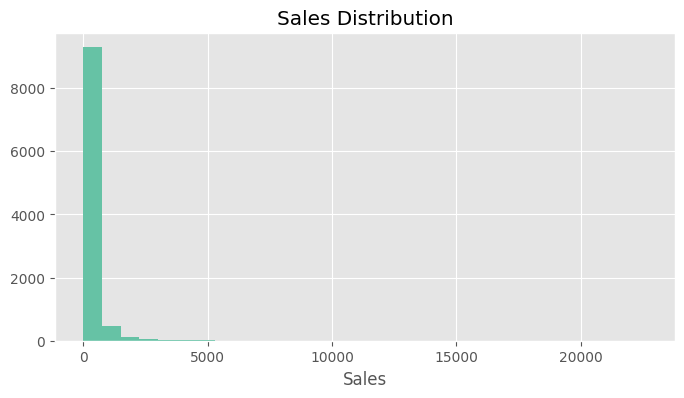

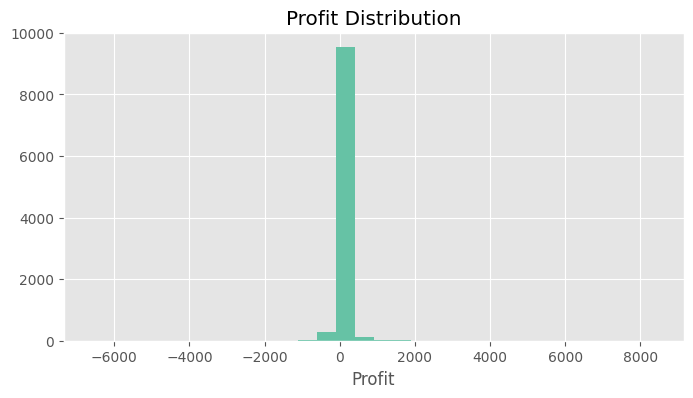

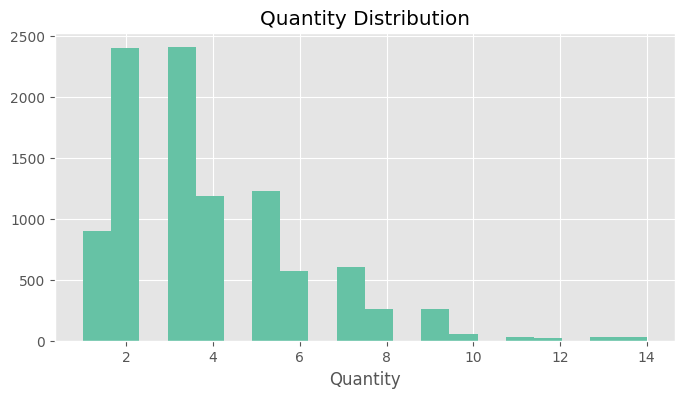

In [33]:
plt.figure(figsize=(8,4))
plt.hist(df['Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df['Quantity'], bins=20)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.show()

**CATEGORY ANALYSIS**

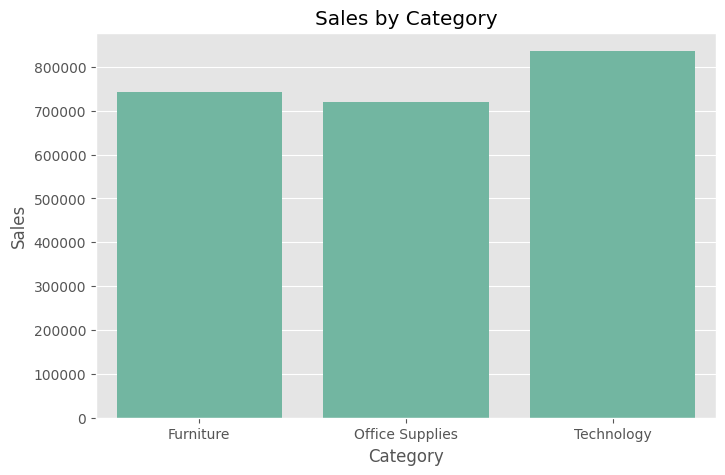

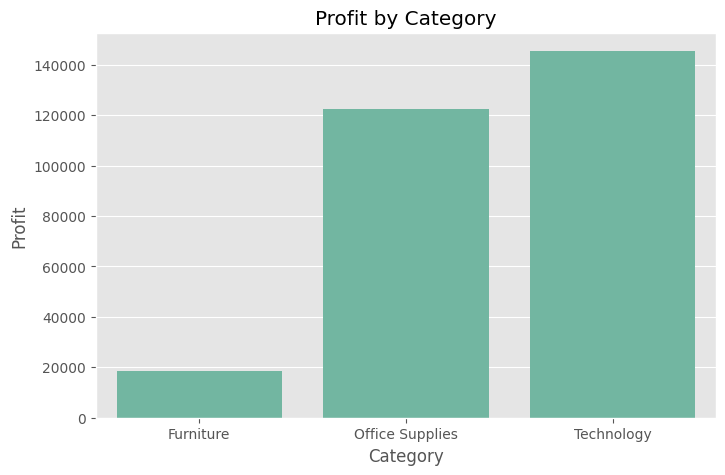

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df, estimator=sum, errorbar=None)
plt.title("Sales by Category")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df, estimator=sum, errorbar=None)
plt.title("Profit by Category")
plt.show()

**REGION ANALYSIS**

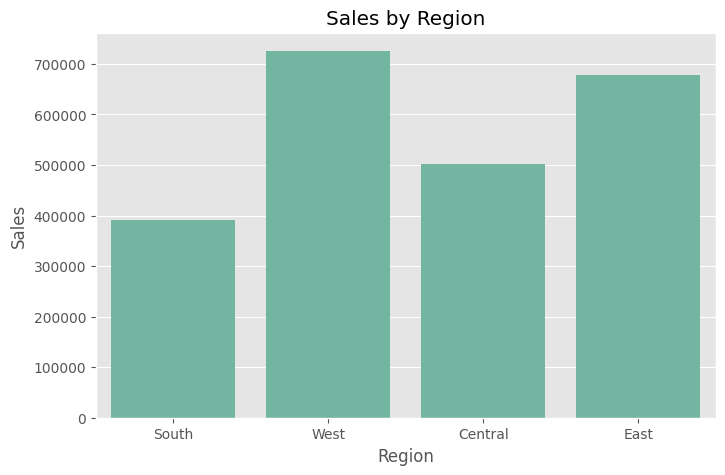

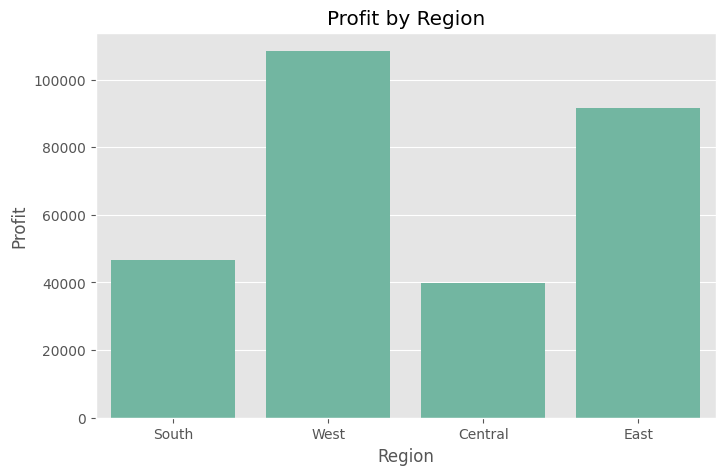

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum, errorbar=None)
plt.title("Sales by Region")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Region', y='Profit', data=df, estimator=sum, errorbar=None)
plt.title("Profit by Region")
plt.show()

**DISCOUNT IMPACT**

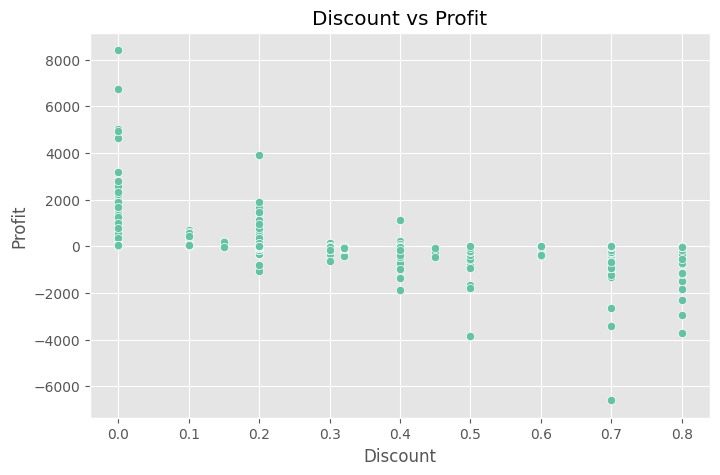

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

**PRODUCT ANALYSIS**

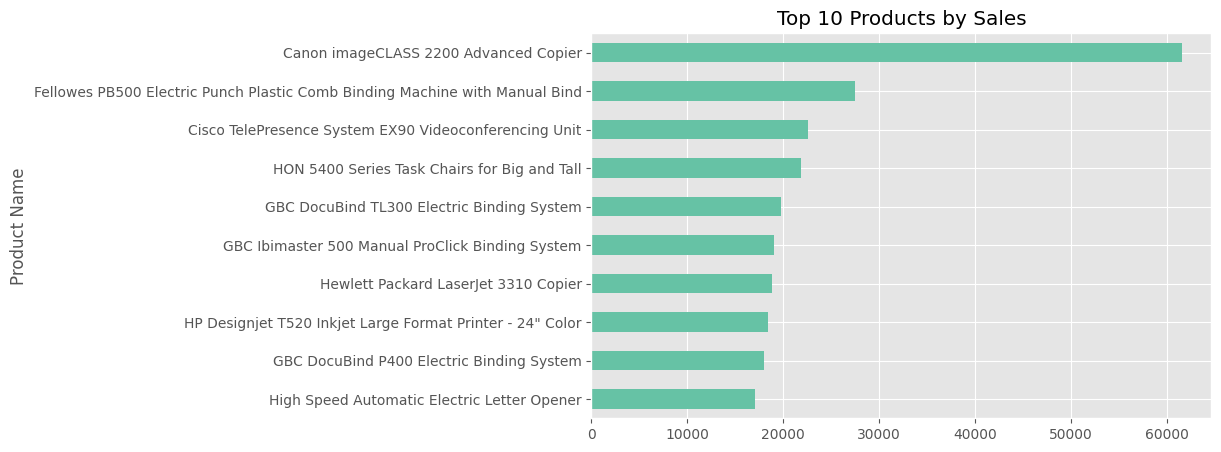

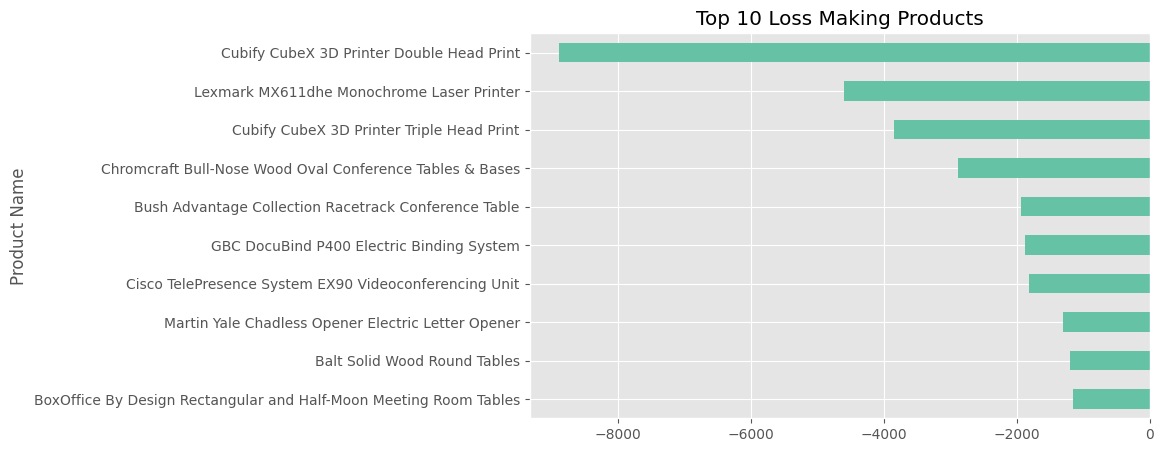

In [37]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Products by Sales")
plt.gca().invert_yaxis()
plt.show()

loss_products = df.groupby('Product Name')['Profit'].sum().sort_values().head(10)

loss_products.plot(kind='barh', figsize=(8,5))
plt.title("Top 10 Loss Making Products")
plt.gca().invert_yaxis()
plt.show()

**TIME ANALYSIS**

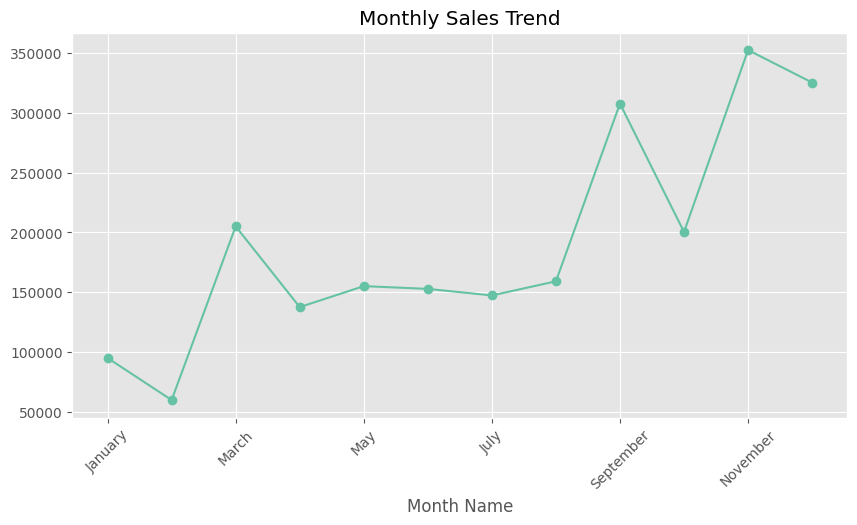

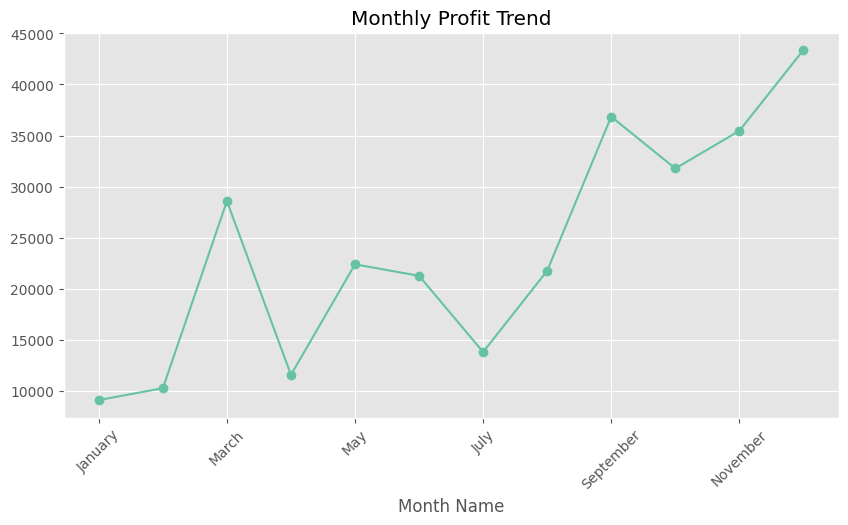

In [38]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = df.groupby('Month Name')['Sales'].sum().reindex(month_order)
monthly_profit = df.groupby('Month Name')['Profit'].sum().reindex(month_order)

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

monthly_profit.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Monthly Profit Trend")
plt.xticks(rotation=45)
plt.show()

**CUSTOMER SEGMENT ANALYSIS**

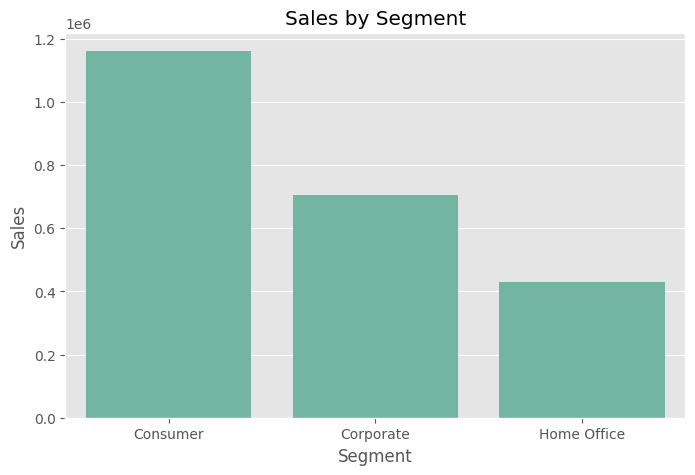

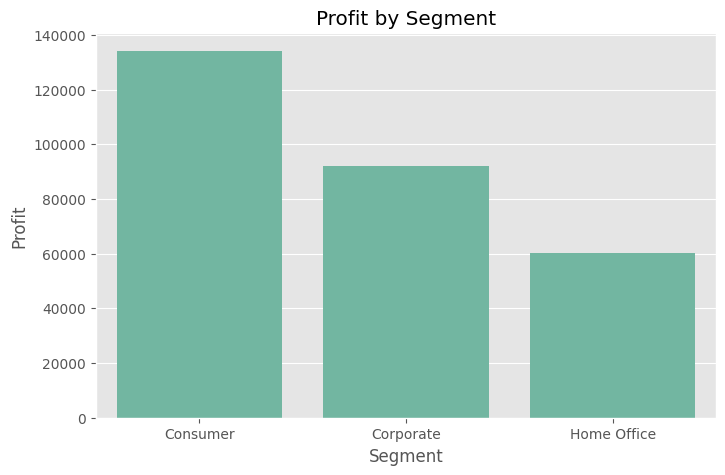

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Sales', data=df, estimator=sum, errorbar=None)
plt.title("Sales by Segment")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x='Segment', y='Profit', data=df, estimator=sum, errorbar=None)
plt.title("Profit by Segment")
plt.show()

**CORRELATION HEATMAP**

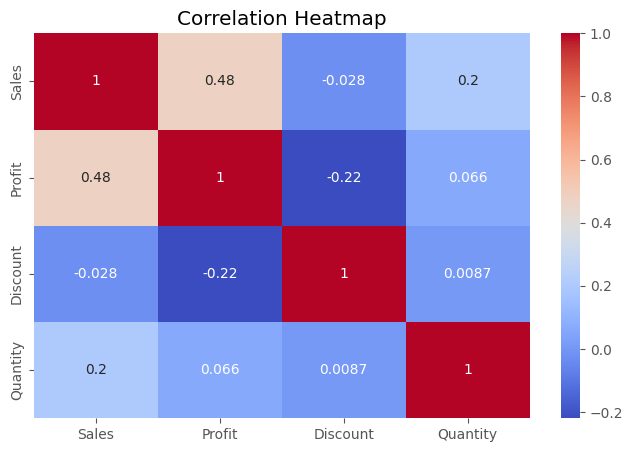

In [40]:
plt.figure(figsize=(8,5))
corr = df[['Sales','Profit','Discount','Quantity']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**BUSINESS INSIGHTS**

In [41]:
print("\nCategory with Highest Sales:")
print(df.groupby('Category')['Sales'].sum().idxmax())

print("\nCategory with Highest Profit:")
print(df.groupby('Category')['Profit'].sum().idxmax())

print("\nBest Region:")
print(df.groupby('Region')['Profit'].sum().idxmax())

print("\nLoss Making Region:")
print(df.groupby('Region')['Profit'].sum().idxmin())

print("\nTop Buying Segment:")
print(df.groupby('Segment')['Sales'].sum().idxmax())

print("\nMost Profitable Segment:")
print(df.groupby('Segment')['Profit'].sum().idxmax())

print("\nMonth with Highest Sales:")
print(monthly_sales.idxmax())


Category with Highest Sales:
Technology

Category with Highest Profit:
Technology

Best Region:
West

Loss Making Region:
Central

Top Buying Segment:
Consumer

Most Profitable Segment:
Consumer

Month with Highest Sales:
November


# **PROJECT CONCLUSION**


*  Technology category gives highest profit.
*  Furniture has good sales but lower profit.
*  High discounts reduce profitability.
*  Some products generate losses
*  Sales peak during Nov-Dec.
*  Focus on profitable products and control discounts.








**SAVE & DOWNLOAD CLEANED DATASET**

In [42]:


# Save cleaned dataset as Excel
df.to_excel('/content/Cleaned_Superstore.xlsx', index=False)

# Save cleaned dataset as CSV
df.to_csv('/content/Cleaned_Superstore.csv', index=False)

print("✅ Cleaned dataset saved successfully!")

# Download the Excel file
from google.colab import files
files.download('/content/Cleaned_Superstore.xlsx')

# If you prefer CSV
# files.download('/content/Cleaned_Superstore.csv')

✅ Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>